In [1]:
from pathlib import Path
import os
import subprocess
import tempfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch

from IPython.display import Audio, display, Markdown
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

In [1]:
# ============================================================
# Cell 2 — Imports and project paths
# Purpose:
#   Import required libraries and load canonical project paths
#   from src.config.
#
# Important:
#   This avoids hard-coded machine-specific paths.
# ============================================================

from pathlib import Path
import sys
import os
import json
import subprocess
import tempfile
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch

from IPython.display import Audio, display, Markdown
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

# Detect project root from notebook location
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Could not find project root containing src/.")

sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    PROJECT_ROOT,
    INTERIM_DIR,
    OUTPUT_DIR,
    FIG_DIR,
    LOG_DIR,
    RECORDING_MANIFEST_FILE,
    RANDOM_SEED,
)

print("Project root:", PROJECT_ROOT)
print("Recording manifest:", RECORDING_MANIFEST_FILE)

Project root: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\paper1_pipeline
Recording manifest: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\paper1_pipeline\data\interim\recording_manifest_with_metadata_and_paths.csv


In [30]:
# ============================================================
# Cell 3 — Segmentation output configuration
# Purpose:
#   Define output folders and run-control flags for Silero segmentation.
#
# Important:
#   RUN_FULL_SEGMENTATION is intentionally False by default so the
#   full dataset is not accidentally reprocessed.
# ============================================================

# -----------------------------
# Run-control flags
# -----------------------------

RUN_SMOKE_TEST = True
RUN_RANDOM_BATCH_TEST = True
RUN_FULL_SEGMENTATION = True 
SAVE_SEGMENT_ARTIFACTS = True
SAVE_DIAGNOSTIC_PLOTS = True

# -----------------------------
# Output folders
# -----------------------------

SILERO_OUTPUT_DIR = OUTPUT_DIR / "segmentation" / "silero"
SILERO_SEGMENTS_DIR = SILERO_OUTPUT_DIR / "segments"
SILERO_FRAMES_DIR = SILERO_OUTPUT_DIR / "frames"
SILERO_SUMMARY_DIR = SILERO_OUTPUT_DIR / "summary"

SILERO_PLOTS_DIR = FIG_DIR / "segmentation" / "silero"
SILERO_PLOTS_ACCEPTED_DIR = SILERO_PLOTS_DIR / "accepted"
SILERO_PLOTS_FLAGGED_DIR = SILERO_PLOTS_DIR / "flagged"
SILERO_PLOTS_EXCLUDED_DIR = SILERO_PLOTS_DIR / "excluded"

for directory in [
    SILERO_OUTPUT_DIR,
    SILERO_SEGMENTS_DIR,
    SILERO_FRAMES_DIR,
    SILERO_SUMMARY_DIR,
    SILERO_PLOTS_DIR,
    SILERO_PLOTS_ACCEPTED_DIR,
    SILERO_PLOTS_FLAGGED_DIR,
    SILERO_PLOTS_EXCLUDED_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Silero output directory:", SILERO_OUTPUT_DIR)
print("Silero figure directory:", SILERO_PLOTS_DIR)

Silero output directory: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\paper1_pipeline\outputs\segmentation\silero
Silero figure directory: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\paper1_pipeline\outputs\figures\segmentation\silero


In [21]:
# ============================================================
# Cell 4 — Silero and ffmpeg configuration
# Purpose:
#   Define audio decoding and Silero VAD parameters.
#
# Important:
#   These parameters should be reported or archived because they
#   affect segmentation results.
# ============================================================

# -----------------------------
# ffmpeg
# -----------------------------

FFMPEG_BIN = Path(r"C:\ffmpeg\bin\ffmpeg.exe")

if not FFMPEG_BIN.exists():
    raise FileNotFoundError(
        f"ffmpeg executable not found: {FFMPEG_BIN}\n"
        "Update FFMPEG_BIN to match your installation."
    )

# -----------------------------
# Silero VAD parameters
# -----------------------------

TARGET_SR = 16000
SILERO_THRESHOLD = 0.5
MIN_SPEECH_DURATION_MS = 250
MIN_SILENCE_DURATION_MS = 100
SPEECH_PAD_MS = 50
FRAME_MS = 30

silero_config = {
    "target_sr": TARGET_SR,
    "silero_threshold": SILERO_THRESHOLD,
    "min_speech_duration_ms": MIN_SPEECH_DURATION_MS,
    "min_silence_duration_ms": MIN_SILENCE_DURATION_MS,
    "speech_pad_ms": SPEECH_PAD_MS,
    "frame_ms": FRAME_MS,
    "ffmpeg_bin": str(FFMPEG_BIN),
    "run_timestamp": datetime.now().isoformat(),
}

config_path = LOG_DIR / "silero_segmentation_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(silero_config, f, indent=2)

print("ffmpeg exists:", FFMPEG_BIN.exists())
print("Silero config saved:", config_path)
display(pd.DataFrame([silero_config]))

ffmpeg exists: True
Silero config saved: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\paper1_pipeline\outputs\logs\silero_segmentation_config.json


,target_sr,silero_threshold,min_speech_duration_ms,min_silence_duration_ms,speech_pad_ms,frame_ms,ffmpeg_bin,run_timestamp
0,16000,0.5,250,100,50,30,C:\ffmpeg\bin\ffmpeg.exe,2026-05-22T16:44:23.886871


In [22]:
# ============================================================
# Cell 5 — Load recording manifest
# Purpose:
#   Load the recording manifest containing file names, file paths,
#   participant IDs, diagnosis labels, and metadata.
#
# Important:
#   This notebook expects one row per recording candidate with a
#   valid file_path for audio segmentation.
# ============================================================

if not RECORDING_MANIFEST_FILE.exists():
    raise FileNotFoundError(
        f"Recording manifest not found: {RECORDING_MANIFEST_FILE}"
    )

df_manifest = pd.read_csv(RECORDING_MANIFEST_FILE)

if "Recording date" in df_manifest.columns:
    df_manifest["Recording date"] = pd.to_datetime(
        df_manifest["Recording date"],
        errors="coerce",
    )

required_cols = [
    "file_name",
    "file_path",
    "ID_norm",
    "Diagnosis",
]

missing_cols = [
    col for col in required_cols
    if col not in df_manifest.columns
]

if missing_cols:
    raise ValueError(f"Manifest missing required columns: {missing_cols}")

manifest_summary = pd.DataFrame({
    "metric": [
        "n_rows",
        "n_unique_file_names",
        "n_rows_with_file_path",
        "n_unique_subjects",
    ],
    "value": [
        len(df_manifest),
        df_manifest["file_name"].nunique(),
        df_manifest["file_path"].notna().sum(),
        df_manifest["ID_norm"].nunique(),
    ],
})

display(manifest_summary)
display(df_manifest.head())

,metric,value
0,n_rows,598
1,n_unique_file_names,598
2,n_rows_with_file_path,598
3,n_unique_subjects,236


,file_name,media_stem,subject_id,ID_norm,Diagnosis,Recording date,Task Name,Extension,bulbar_score,alsfrs_total,severity_bin,Task Completed as Instructed,Needs Parsing,Another Person Speaks,Background Noise,Volume is Unstable,Poor Audio Quality,indexed_file_name,file_path,audio_root
0,CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav,CAPT0000001_272_1_20220518_240_PSG_BAMBOO,CAPT0000001,CAPT0000001,ALS,2022-05-18,Bamboo passage,.wav,9.0,45.0,Mild (9–10),Yes,Yes,No,Yes,No,No,CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...
1,CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav,CAPT0000002_272_2_20221114_240_PSG_BAMBOO,CAPT0000002,CAPT0000002,ALS,2022-11-14,Bamboo passage,.wav,12.0,37.0,Normal (11–12),Yes,Yes,No,Yes,No,No,CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...
2,CAPT0000003_272_1_20220623_240_PSG_BAMBOO.wav,CAPT0000003_272_1_20220623_240_PSG_BAMBOO,CAPT0000003,CAPT0000003,Control,2022-06-23,Bamboo passage,.wav,NaN,NaN,NaN,Yes,Yes,No,Yes,No,No,CAPT0000003_272_1_20220623_240_PSG_BAMBOO.wav,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...
3,CAPT0000003_272_2_20230315_240_PSG_BAMBOO.wav,CAPT0000003_272_2_20230315_240_PSG_BAMBOO,CAPT0000003,CAPT0000003,Control,2023-03-15,Bamboo passage,.wav,NaN,NaN,NaN,Yes,Yes,No,Yes,No,No,CAPT0000003_272_2_20230315_240_PSG_BAMBOO.wav,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...
4,CAPT0000004_272_2_20221208_240_PSG_BAMBOO.wav,CAPT0000004_272_2_20221208_240_PSG_BAMBOO,CAPT0000004,CAPT0000004,ALS,2022-12-08,Bamboo passage,.wav,12.0,43.0,Normal (11–12),Yes,Yes,No,Yes,No,No,CAPT0000004_272_2_20221208_240_PSG_BAMBOO.wav,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...


In [23]:
# ============================================================
# Cell 6 — Validate audio file paths
# Purpose:
#   Check whether manifest file paths exist before segmentation.
#
# Important:
#   Missing paths are saved to a table and excluded from the run.
# ============================================================

df_manifest["file_path_exists"] = df_manifest["file_path"].apply(
    lambda x: Path(x).exists() if pd.notna(x) else False
)

path_check_summary = pd.DataFrame({
    "metric": [
        "rows_total",
        "rows_with_file_path",
        "existing_file_paths",
        "missing_file_paths",
    ],
    "value": [
        len(df_manifest),
        df_manifest["file_path"].notna().sum(),
        int(df_manifest["file_path_exists"].sum()),
        int((df_manifest["file_path"].notna() & ~df_manifest["file_path_exists"]).sum()),
    ],
})

display(path_check_summary)

missing_path_df = df_manifest.loc[
    df_manifest["file_path"].notna() & ~df_manifest["file_path_exists"],
    ["file_name", "file_path", "ID_norm", "Diagnosis"]
].copy()

if len(missing_path_df) > 0:
    missing_path_file = SILERO_SUMMARY_DIR / "silero_missing_file_paths.csv"
    missing_path_df.to_csv(missing_path_file, index=False)
    print("Saved missing path table:", missing_path_file)

run_df = (
    df_manifest
    .loc[df_manifest["file_path_exists"]]
    .copy()
    .reset_index(drop=True)
)

print("Files available for segmentation:", len(run_df))

,metric,value
0,rows_total,598
1,rows_with_file_path,598
2,existing_file_paths,598
3,missing_file_paths,0


Files available for segmentation: 598


In [24]:
# ============================================================
# Cell 7 — Audio decoding function
# Purpose:
#   Decode arbitrary audio files to mono 16 kHz waveform using ffmpeg.
#
# Important:
#   This creates a consistent waveform input for Silero VAD and all
#   downstream feature extraction steps.
# ============================================================

def decode_audio_ffmpeg(
    file_path,
    target_sr=16000,
    mono=True,
    ffmpeg_bin=FFMPEG_BIN,
):
    """
    Decode an audio/video file using ffmpeg and return a mono waveform.

    Returns:
        dict with waveform, sample rate, duration, and source path.
    """
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        tmp_wav = tmp.name

    try:
        cmd = [
            str(ffmpeg_bin),
            "-y",
            "-i", str(file_path),
            "-vn",
            "-ac", "1" if mono else "2",
            "-ar", str(target_sr),
            "-f", "wav",
            tmp_wav,
        ]

        completed = subprocess.run(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            check=False,
        )

        if completed.returncode != 0:
            raise RuntimeError(
                f"ffmpeg failed for:\n{file_path}\n\nSTDERR:\n{completed.stderr}"
            )

        x, sr = sf.read(tmp_wav)

        if np.ndim(x) == 2:
            x = np.mean(x, axis=1)

        x = np.asarray(x, dtype=np.float32)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        x = np.clip(x, -1.0, 1.0)

        return {
            "x": x,
            "sr": int(sr),
            "duration_sec": float(len(x) / sr) if sr > 0 else np.nan,
            "file_path": str(file_path),
        }

    finally:
        if os.path.exists(tmp_wav):
            try:
                os.remove(tmp_wav)
            except OSError:
                pass

In [25]:
# ============================================================
# Cell 8 — Load Silero wrapper and model
# Purpose:
#   Import local Silero wrapper functions and load the Silero VAD model.
#
# Important:
#   The wrapper file must exist in src/ or be importable from the project.
# ============================================================

# If the wrapper is currently in the old src folder, move/copy it into:
#   paper1_pipeline/src/segmentation_wrapper_silero_v1.py

try:
    from src.segmentation_wrapper_silero_v1 import (
        build_silero_stage_from_audio,
        summarize_silero_stage,
    )
except ImportError:
    # Fallback if src is already on sys.path and wrapper is imported directly
    from segmentation_wrapper_silero_v1 import (
        build_silero_stage_from_audio,
        summarize_silero_stage,
    )

model, utils = torch.hub.load(
    repo_or_dir="snakers4/silero-vad",
    model="silero_vad",
    force_reload=False,
    trust_repo=True,
)

get_speech_timestamps = None

for obj in utils:
    if callable(obj) and getattr(obj, "__name__", "") == "get_speech_timestamps":
        get_speech_timestamps = obj
        break

if get_speech_timestamps is None:
    raise RuntimeError("Could not locate get_speech_timestamps in Silero utils.")

print("Silero model loaded.")
print("get_speech_timestamps:", get_speech_timestamps)

Silero model loaded.
get_speech_timestamps: <function get_speech_timestamps at 0x00000210389BB7F0>


Using cache found in C:\Users\musikicn/.cache\torch\hub\snakers4_silero-vad_master


In [26]:
# ============================================================
# Cell 9 — Segmentation QC rules
# Purpose:
#   Classify Silero segmentation outputs as accepted, flagged, or excluded.
#
# Important:
#   These are segmentation reliability flags, not final human quality labels.
#   Keep thresholds lenient because ALS speech can be slow, paused, or weak.
# ============================================================

def classify_silero_summary_reading_task(summary):
    """
    Reading-task-specific segmentation triage.
    """
    flags = []

    speech_fraction = summary.get("speech_fraction", np.nan)
    n_speech_segments = summary.get("n_speech_segments", 0)
    longest_internal_pause = summary.get("longest_internal_nonspeech_sec", 0.0)
    duration_sec = summary.get("duration_sec", np.nan)
    rms_db_median = summary.get("rms_db_median", np.nan)
    rms_db_std = summary.get("rms_db_std", np.nan)

    # Hard exclusions
    if n_speech_segments == 0:
        flags.append("no_speech_detected")

    if pd.notna(speech_fraction) and speech_fraction < 0.05:
        flags.append("very_low_speech_fraction")

    if pd.notna(duration_sec) and duration_sec < 1.0:
        flags.append("very_short_file")

    if pd.notna(rms_db_median) and pd.notna(rms_db_std):
        if rms_db_median < -60 and rms_db_std < 3:
            flags.append("near_silent_or_noise_only")

    # Soft review flags
    if n_speech_segments > 25:
        flags.append("extreme_fragmentation")

    if pd.notna(longest_internal_pause) and longest_internal_pause > 5.0:
        flags.append("extreme_internal_pause")

    hard_flags = {
        "no_speech_detected",
        "very_low_speech_fraction",
        "very_short_file",
        "near_silent_or_noise_only",
    }

    soft_flags = {
        "extreme_fragmentation",
        "extreme_internal_pause",
    }

    if any(flag in flags for flag in hard_flags):
        status = "excluded"
    elif any(flag in flags for flag in soft_flags):
        status = "flagged"
    else:
        status = "accepted"

    return {
        "qc_status": status,
        "qc_flags": ";".join(flags),
    }

In [27]:
# ============================================================
# Cell 10 — Diagnostic plotting function
# Purpose:
#   Create per-recording diagnostic plots showing waveform, RMS,
#   Silero speech mask, and segment labels.
#
# Important:
#   These plots are for segmentation QC and troubleshooting.
#   They are not manuscript figures.
# ============================================================

# Paste your existing plot_silero_stage(...) function here.

def plot_silero_stage(stage, file_name=None, save_path=None, show=True):
    """
    Diagnostic plot, same style as your WebRTC notebook.
    """
    audio = stage["audio"]
    frame_df = stage["frame_df"]
    segments_df = stage["segments_df"]
    boundaries_df = stage["boundaries_df"]

    x = audio["x_analysis"]
    sr = audio["sr_analysis"]

    t_wave = np.arange(len(x)) / sr if len(x) > 0 else np.array([])

    fig, axes = plt.subplots(
        4, 1,
        figsize=(14, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [2.0, 1.5, 1.2, 1.2]}
    )
    ax0, ax1, ax2, ax3 = axes

    duration_sec = audio.get("duration_analysis_sec", np.nan)
    speech_fraction = float(frame_df["speech_vad_smooth"].astype(bool).mean()) if len(frame_df) else np.nan
    n_speech_segments = int((segments_df["segment_type"] == "speech").sum()) if len(segments_df) else 0

    title_main = file_name if file_name is not None else "Silero segmentation"
    title_sub = f"duration={duration_sec:.2f}s | speech_fraction={speech_fraction:.3f} | n_speech_segments={n_speech_segments}"
    fig.suptitle(f"{title_main}\n{title_sub}", y=0.98, fontsize=11)

    if len(x) > 0:
        ax0.plot(t_wave, x, linewidth=0.5)
    ax0.axhline(0, linewidth=0.6, alpha=0.5)
    ax0.set_ylabel("Amplitude")

    if len(frame_df) > 0:
        ax1.plot(frame_df["mid_sec"], frame_df["rms_db"], linewidth=0.8, label="RMS dB")
        ax1.legend(loc="upper right", fontsize=8)
    ax1.set_ylabel("RMS dB")

    if len(frame_df) > 0:
        mid = frame_df["mid_sec"].values
        smooth = frame_df["speech_vad_smooth"].astype(int).values
        ax2.step(mid, smooth + 0.0, where="mid", label="Silero speech mask")
        ax2.legend(loc="upper right", fontsize=8)

    ax2.set_yticks([])
    ax2.set_ylabel("Masks")

    role_colors = {
        "speech": "#66bb6a",
        "leading_nonspeech": "#9e9e9e",
        "internal_nonspeech": "#ffa726",
        "trailing_nonspeech": "#ab47bc",
    }

    used_labels = set()

    if len(segments_df) > 0:
        for _, seg in segments_df.iterrows():
            role = seg["segment_role"]
            label = role if role not in used_labels else None
            used_labels.add(role)

            if role == "speech":
                ymin, ymax = 0.5, 1.0
            else:
                ymin, ymax = 0.0, 0.5

            ax3.axvspan(
                seg["start_sec"],
                seg["end_sec"],
                ymin=ymin,
                ymax=ymax,
                alpha=0.35,
                color=role_colors.get(role, "#bdbdbd"),
                label=label
            )

    if len(boundaries_df) > 0:
        for _, b in boundaries_df.iterrows():
            ax3.axvline(b["boundary_sec"], linestyle="--", linewidth=0.5, alpha=0.4, color="black")

    ax3.set_ylim(0, 2)
    ax3.set_yticks([0.5, 1.5])
    ax3.set_yticklabels(["non-speech", "speech"])
    ax3.set_xlabel("Time (s)")
    ax3.set_ylabel("Segments")
    if len(used_labels) > 0:
        ax3.legend(loc="upper right", fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.94])

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes

In [13]:
# ============================================================
# Cell 11 — Per-recording segmentation runner
# Purpose:
#   Define helper functions to run Silero VAD on one recording and
#   save segment/frame/plot artifacts.
#
# Important:
#   This is the core unit of segmentation. The full-run cell simply
#   applies this function to every valid recording.
# ============================================================

def build_artifact_paths(row):
    stem = Path(row["file_name"]).stem

    return {
        "stem": stem,
        "segments_path": SILERO_SEGMENTS_DIR / f"{stem}_segments.csv",
        "frames_path": SILERO_FRAMES_DIR / f"{stem}_frames.csv",
        "accepted_plot_path": SILERO_PLOTS_ACCEPTED_DIR / f"{stem}_silero.png",
        "flagged_plot_path": SILERO_PLOTS_FLAGGED_DIR / f"{stem}_silero.png",
        "excluded_plot_path": SILERO_PLOTS_EXCLUDED_DIR / f"{stem}_silero.png",
    }


def choose_plot_path(qc_status, paths):
    if qc_status == "accepted":
        return paths["accepted_plot_path"]
    if qc_status == "flagged":
        return paths["flagged_plot_path"]
    return paths["excluded_plot_path"]


def run_silero_for_row(
    row,
    save_artifacts=True,
    save_plot=True,
):
    """
    Full per-recording segmentation pipeline:
        1. Decode audio using ffmpeg
        2. Run Silero VAD
        3. Summarize segmentation
        4. Classify segmentation QC status
        5. Save segment/frame/plot artifacts
    """
    if pd.isna(row["file_path"]):
        raise ValueError("Missing file_path")

    decoded = decode_audio_ffmpeg(
        row["file_path"],
        target_sr=TARGET_SR,
        mono=True,
        ffmpeg_bin=FFMPEG_BIN,
    )

    stage = build_silero_stage_from_audio(
        decoded["x"],
        decoded["sr"],
        model=model,
        get_speech_timestamps_fn=get_speech_timestamps,
        threshold=SILERO_THRESHOLD,
        min_speech_duration_ms=MIN_SPEECH_DURATION_MS,
        min_silence_duration_ms=MIN_SILENCE_DURATION_MS,
        speech_pad_ms=SPEECH_PAD_MS,
        return_seconds=False,
        frame_ms=FRAME_MS,
    )

    summary = summarize_silero_stage(stage, row=row)
    summary.update(classify_silero_summary_reading_task(summary))

    paths = build_artifact_paths(row)

    if save_artifacts:
        stage["segments_df"].to_csv(paths["segments_path"], index=False)
        stage["frame_df"].to_csv(paths["frames_path"], index=False)
        summary["segments_path"] = str(paths["segments_path"])
        summary["frames_path"] = str(paths["frames_path"])
    else:
        summary["segments_path"] = pd.NA
        summary["frames_path"] = pd.NA

    if save_plot:
        plot_path = choose_plot_path(summary["qc_status"], paths)
        plot_silero_stage(
            stage,
            file_name=f"{row['file_name']} | silero_vad",
            save_path=plot_path,
            show=False,
        )
        summary["plot_path"] = str(plot_path)
    else:
        summary["plot_path"] = pd.NA

    return {
        "summary": summary,
        "stage": stage,
    }

,method,duration_sec,sample_rate_analysis,threshold,frame_ms,min_speech_duration_ms,min_silence_duration_ms,speech_pad_ms,n_frames,n_segments_total,...,file_path,ID_norm,Diagnosis,severity_bin,Recording date,qc_status,qc_flags,segments_path,frames_path,plot_path
0,silero_vad,64.68,16000,0.5,30,250,100,50,2156,25,...,C:\Users\musikicn\OneDrive - University of Tor...,CAPT0000001,ALS,Mild (9–10),2022-05-18,accepted,,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...


### Smoke test recording: CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav

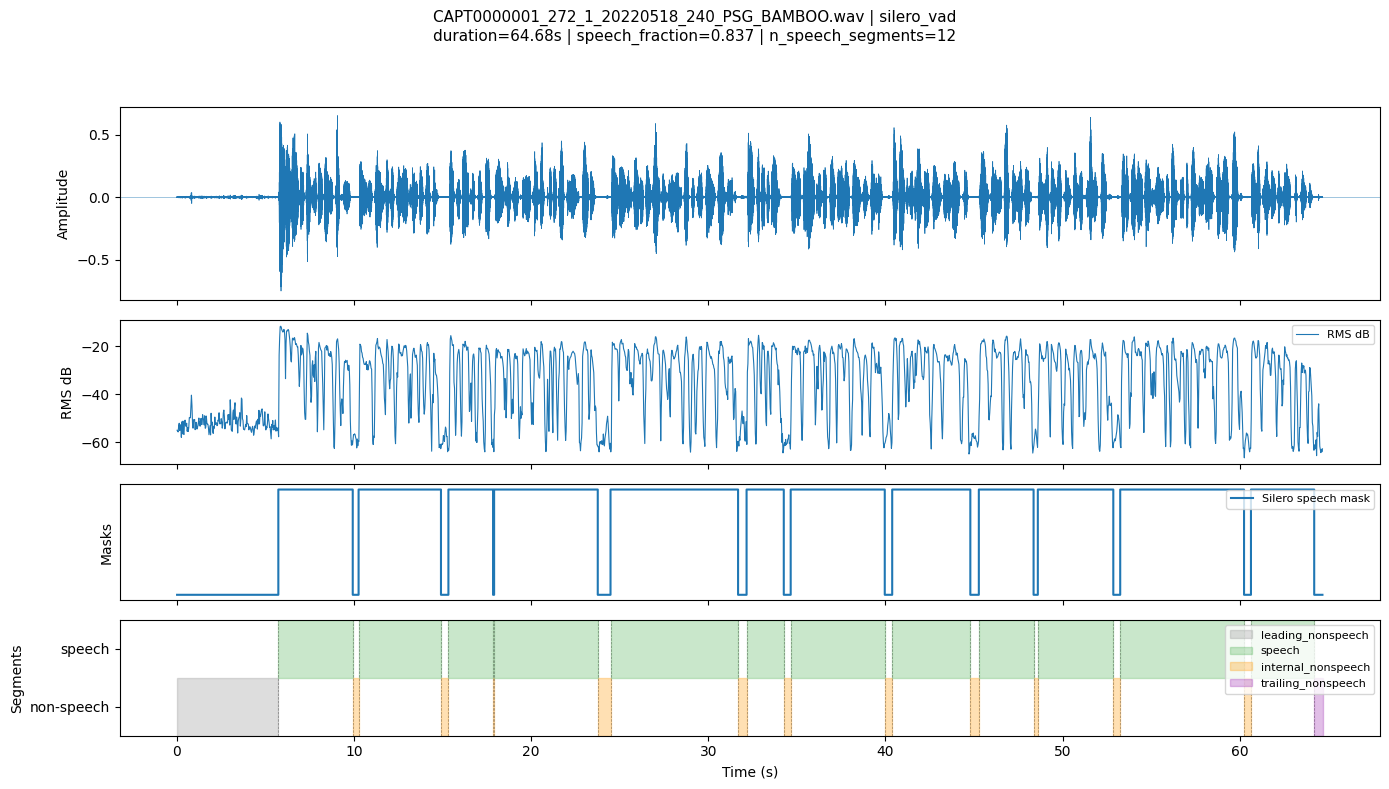

In [14]:
# ============================================================
# Cell 12 — Smoke test on one recording
# Purpose:
#   Run Silero VAD on one available recording before processing
#   the full dataset.
#
# Important:
#   This confirms ffmpeg, Silero, wrapper functions, and output
#   writing work correctly.
# ============================================================

if RUN_SMOKE_TEST:
    if len(run_df) == 0:
        raise ValueError("No valid recordings available for smoke test.")

    test_row = run_df.iloc[0]

    test_result = run_silero_for_row(
        test_row,
        save_artifacts=SAVE_SEGMENT_ARTIFACTS,
        save_plot=SAVE_DIAGNOSTIC_PLOTS,
    )

    display(pd.DataFrame([test_result["summary"]]))

    display(Markdown(f"### Smoke test recording: {test_row['file_name']}"))

    plot_silero_stage(
        test_result["stage"],
        file_name=f"{test_row['file_name']} | silero_vad",
        show=True,
    )
else:
    print("RUN_SMOKE_TEST is False; skipped.")

In [28]:
# ============================================================
# Cell 13 — Optional random batch test
# Purpose:
#   Run segmentation on a small random subset to catch batch-level
#   errors before running the full dataset.
#
# Important:
#   Set RUN_RANDOM_BATCH_TEST = True in Cell 3 to enable this.
# ============================================================

if RUN_RANDOM_BATCH_TEST:
    batch_df = (
        run_df
        .sample(n=min(10, len(run_df)), random_state=RANDOM_SEED)
        .reset_index(drop=True)
    )

    batch_results = []
    batch_errors = []

    for _, row in tqdm(batch_df.iterrows(), total=len(batch_df), desc="Silero batch test"):
        try:
            out = run_silero_for_row(
                row,
                save_artifacts=SAVE_SEGMENT_ARTIFACTS,
                save_plot=SAVE_DIAGNOSTIC_PLOTS,
            )
            batch_results.append(out["summary"])
        except Exception as exc:
            batch_errors.append({
                "file_name": row.get("file_name", pd.NA),
                "file_path": row.get("file_path", pd.NA),
                "ID_norm": row.get("ID_norm", pd.NA),
                "Diagnosis": row.get("Diagnosis", pd.NA),
                "error": str(exc),
            })

    silero_batch_df = pd.DataFrame(batch_results)
    silero_batch_errors_df = pd.DataFrame(batch_errors)

    display(silero_batch_df.head())
    display(silero_batch_errors_df.head())

    print("Batch successes:", len(silero_batch_df))
    print("Batch errors:", len(silero_batch_errors_df))
else:
    print("RUN_RANDOM_BATCH_TEST is False; skipped.")

Silero batch test:   0%|          | 0/10 [00:00<?, ?it/s]

,method,duration_sec,sample_rate_analysis,threshold,frame_ms,min_speech_duration_ms,min_silence_duration_ms,speech_pad_ms,n_frames,n_segments_total,...,file_path,ID_norm,Diagnosis,severity_bin,Recording date,qc_status,qc_flags,segments_path,frames_path,plot_path
0,silero_vad,56.160000,16000,0.5,30,250,100,50,1872,23,...,C:\Users\musikicn\OneDrive - University of Tor...,CAPT0000060,ALS,Normal (11–12),2024-11-08,accepted,,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...
1,silero_vad,40.788688,16000,0.5,30,250,100,50,1360,23,...,C:\Users\musikicn\OneDrive - University of Tor...,MIBD36,ALS,Mild (9–10),2023-11-26,accepted,,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...
2,silero_vad,43.452813,16000,0.5,30,250,100,50,1449,23,...,C:\Users\musikicn\OneDrive - University of Tor...,TIBD86,ALS,Normal (11–12),2023-10-26,accepted,,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...
3,silero_vad,46.500000,16000,0.5,30,250,100,50,1550,21,...,C:\Users\musikicn\OneDrive - University of Tor...,CAPT0000037,ALS,Normal (11–12),2024-06-04,accepted,,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...
4,silero_vad,111.360000,16000,0.5,30,250,100,50,3712,115,...,C:\Users\musikicn\OneDrive - University of Tor...,CAPT0000112,ALS,Severe (≤5),2024-07-18,flagged,extreme_fragmentation,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...,C:\Users\musikicn\OneDrive - University of Tor...


""


Batch successes: 10
Batch errors: 0


In [31]:
# ============================================================
# Cell 14 — Full Silero segmentation run
# Purpose:
#   Run Silero segmentation on every valid recording in the manifest.
#
# Important:
#   This can take time and writes many files. It only runs when
#   RUN_FULL_SEGMENTATION = True in Cell 3.
# ============================================================

if RUN_FULL_SEGMENTATION:
    results_all = []
    errors_all = []

    for _, row in tqdm(run_df.iterrows(), total=len(run_df), desc="Silero full run"):
        try:
            out = run_silero_for_row(
                row,
                save_artifacts=SAVE_SEGMENT_ARTIFACTS,
                save_plot=SAVE_DIAGNOSTIC_PLOTS,
            )
            results_all.append(out["summary"])
        except Exception as exc:
            errors_all.append({
                "file_name": row.get("file_name", pd.NA),
                "file_path": row.get("file_path", pd.NA),
                "ID_norm": row.get("ID_norm", pd.NA),
                "Diagnosis": row.get("Diagnosis", pd.NA),
                "severity_bin": row.get("severity_bin", pd.NA),
                "Recording date": row.get("Recording date", pd.NA),
                "error": str(exc),
            })

    silero_all_df = pd.DataFrame(results_all)
    silero_errors_df = pd.DataFrame(errors_all)

    print("Finished full run.")
    print("Successful files:", len(silero_all_df))
    print("Errors:", len(silero_errors_df))

else:
    print("RUN_FULL_SEGMENTATION is False; full segmentation skipped.")

    # If previous outputs exist, load them for downstream summary cells.
    summary_file = SILERO_SUMMARY_DIR / "silero_all_summary.csv"
    errors_file = SILERO_SUMMARY_DIR / "silero_all_errors.csv"

    if summary_file.exists():
        silero_all_df = pd.read_csv(summary_file)
        print("Loaded existing summary:", summary_file)
    else:
        silero_all_df = pd.DataFrame()

    if errors_file.exists():
        silero_errors_df = pd.read_csv(errors_file)
        print("Loaded existing errors:", errors_file)
    else:
        silero_errors_df = pd.DataFrame()

Silero full run:   0%|          | 0/598 [00:00<?, ?it/s]

Finished full run.
Successful files: 598
Errors: 0


In [32]:
# ============================================================
# Cell 15 — Save segmentation summary and errors
# Purpose:
#   Save recording-level Silero segmentation summaries and any
#   processing errors.
#
# Important:
#   These files are downstream inputs for feature extraction/QC.
# ============================================================

summary_file = SILERO_SUMMARY_DIR / "silero_all_summary.csv"
errors_file = SILERO_SUMMARY_DIR / "silero_all_errors.csv"

if len(silero_all_df) > 0:
    silero_all_df.to_csv(summary_file, index=False)
    print("Saved summary:", summary_file)
else:
    print("No segmentation summary rows to save.")

if len(silero_errors_df) > 0:
    silero_errors_df.to_csv(errors_file, index=False)
    print("Saved errors:", errors_file)
else:
    pd.DataFrame().to_csv(errors_file, index=False)
    print("No errors; saved empty error file:", errors_file)

Saved summary: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\paper1_pipeline\outputs\segmentation\silero\summary\silero_all_summary.csv
No errors; saved empty error file: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\paper1_pipeline\outputs\segmentation\silero\summary\silero_all_errors.csv


In [33]:
# ============================================================
# Cell 16 — Segmentation QC status summary
# Purpose:
#   Summarize accepted, flagged, and excluded recordings after
#   Silero segmentation.
#
# Important:
#   These counts can be used in manuscript methods/results to report
#   segmentation inclusion/exclusion.
# ============================================================

if len(silero_all_df) == 0:
    print("No Silero summary available.")
else:
    qc_counts = (
        silero_all_df["qc_status"]
        .value_counts(dropna=False)
        .rename_axis("qc_status")
        .reset_index(name="n")
    )

    qc_counts["percent"] = 100 * qc_counts["n"] / qc_counts["n"].sum()

    display(qc_counts)

    qc_counts_file = SILERO_SUMMARY_DIR / "silero_qc_status_counts.csv"
    qc_counts.to_csv(qc_counts_file, index=False)

    print("Saved QC counts:", qc_counts_file)

    if "qc_flags" in silero_all_df.columns:
        top_flags = (
            silero_all_df["qc_flags"]
            .fillna("")
            .replace("", pd.NA)
            .dropna()
            .value_counts()
            .head(20)
            .rename_axis("qc_flags")
            .reset_index(name="n")
        )

        display(top_flags)

        top_flags_file = SILERO_SUMMARY_DIR / "silero_top_qc_flags.csv"
        top_flags.to_csv(top_flags_file, index=False)

        print("Saved top QC flags:", top_flags_file)

,qc_status,n,percent
0,accepted,489,81.772575
1,flagged,67,11.204013
2,excluded,42,7.023411


Saved QC counts: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\paper1_pipeline\outputs\segmentation\silero\summary\silero_qc_status_counts.csv


,qc_flags,n
0,extreme_fragmentation,46
1,no_speech_detected;very_low_speech_fraction;ne...,22
2,extreme_internal_pause,13
3,very_low_speech_fraction,10
4,extreme_fragmentation;extreme_internal_pause,8
5,no_speech_detected;very_low_speech_fraction,6
6,no_speech_detected;very_short_file,2
7,no_speech_detected;very_low_speech_fraction;ve...,2


Saved top QC flags: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\paper1_pipeline\outputs\segmentation\silero\summary\silero_top_qc_flags.csv


In [35]:
# ============================================================
# Cell 17 — Optional manual listening/segment inspection
# Purpose:
#   Listen to one recording and inspect its segment table.
#
# Important:
#   This is manual QC only. It does not modify outputs.
# ============================================================

RUN_MANUAL_LISTENING_CHECK = True

if RUN_MANUAL_LISTENING_CHECK:
    listen_row = run_df.iloc[0]

    listen_result = run_silero_for_row(
        listen_row,
        save_artifacts=False,
        save_plot=False,
    )

    display(Markdown(f"### Full file: {listen_row['file_name']}"))
    display(Audio(filename=listen_row["file_path"]))

    segs = listen_result["stage"]["segments_df"].copy()
    display(segs.head(10))

else:
    print("RUN_MANUAL_LISTENING_CHECK is False; skipped.")

### Full file: CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav

,segment_type,start_sec,end_sec,duration_sec,run_start_frame,run_end_frame,segment_role
0,nonspeech,0.00,5.73,5.73,0,191,leading_nonspeech
1,speech,5.73,9.93,4.20,191,331,speech
2,nonspeech,9.93,10.26,0.33,331,342,internal_nonspeech
3,speech,10.26,14.91,4.65,342,497,speech
4,nonspeech,14.91,15.33,0.42,497,511,internal_nonspeech
5,speech,15.33,17.85,2.52,511,595,speech
6,nonspeech,17.85,17.91,0.06,595,597,internal_nonspeech
7,speech,17.91,23.76,5.85,597,792,speech
8,nonspeech,23.76,24.48,0.72,792,816,internal_nonspeech
9,speech,24.48,31.68,7.20,816,1056,speech
